In [467]:
# load settings
import copy
import re
import typing as t
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression
from matplotlib.ticker import FormatStrFormatter

np.random.seed(42)  # For reproducibility
data_root = Path("/Users/jliu/workspace/lexical_bencmark/dataset")
fig_path = Path(data_root / "fig")

# plotting style configuration and data loading



In [631]:
# Type aliases
DataFrameType = pd.DataFrame
PathType = Path | str


class PlotSettings:
    """Unified plotting settings and styling configuration."""

    COLORS: dict[str, str] = {
        "human_CDI": "#d62728",
        "CHILDES": "orange",
        "stela": "blue",
        "child": "green",
    }

    LINESTYLES: dict[str, str] = {"CHILDES": "-", "child": "-", "LSTM": "-", "trans": "-."}

    DEFAULTS: dict[str, t.Any] = {"label_fontsize": 24, "linewidth": 3.5, "title_fontsize": 28, "grid_color": "#bbbbbb", "figsize": (8, 6), "default_fill_alpha": 0.25}

    FILL_ALPHA: dict[str, float] = {
        "before": 0.1,
        "after": 0.5,
    }

    @staticmethod
    def configure_plot(title: str | None = None, model: str | None = None) -> None:
        """Configure basic plot settings."""
        if title or model:
            plt.title(title or model, fontsize=PlotSettings.DEFAULTS["label_fontsize"], fontweight="bold")
        plt.xticks(fontsize=PlotSettings.DEFAULTS["label_fontsize"])
        plt.yticks(fontsize=PlotSettings.DEFAULTS["label_fontsize"])
        plt.grid(True, linestyle=":", linewidth=1, color=PlotSettings.DEFAULTS["grid_color"])

    @staticmethod
    def configure_legend() -> None:
        """Configure legend settings."""
        plt.legend(
            title="Settings", title_fontsize=PlotSettings.DEFAULTS["title_fontsize"], fontsize=PlotSettings.DEFAULTS["label_fontsize"], loc="upper left", bbox_to_anchor=(1.01, 1)
        )

    @staticmethod
    def configure_legend(outside: bool = True) -> None:
        """Configure legend settings."""
        legend_params = {
            "title": "Settings",
            "title_fontsize": PlotSettings.DEFAULTS["title_fontsize"],
            "fontsize": PlotSettings.DEFAULTS["label_fontsize"],
        }
        if outside:
            legend_params.update({"loc": "upper left", "bbox_to_anchor": (1.01, 1)})
        else:
            legend_params.update(
                {
                    "loc": "best"  # Matplotlib will automatically find best location
                }
            )

        plt.legend(**legend_params)

    @staticmethod
    def save_figure(filepath: str) -> None:
        """Save the current figure to file."""
        plt.tight_layout()
        plt.savefig(filepath, bbox_inches="tight")
        plt.close()

    @staticmethod
    def get_color_palette(n_colors: int) -> list[str]:
        """Get a color palette for the given number of colors."""
        return sns.color_palette("husl", n_colors=n_colors).as_hex()

    @staticmethod
    def apply_style_to_axis(ax: plt.Axes, title: str | None = None) -> None:
        """Apply styling to an existing axis."""
        if title:
            ax.set_title(title, fontsize=PlotSettings.DEFAULTS["title_fontsize"])
        ax.tick_params(labelsize=PlotSettings.DEFAULTS["label_fontsize"])
        ax.grid(True, linestyle=":", linewidth=1, color=PlotSettings.DEFAULTS["grid_color"])


class DataLoader:
    """Unified data loading and preprocessing functionality."""

    @staticmethod
    def get_freq(df: DataFrameType) -> DataFrameType:
        """Annotate frequency of the given column."""
        df = df.copy()
        if "freq" not in df.columns:
            df["freq"] = (df["count"] / df["count"].sum()) * 1_000_000
        df["log_freq"] = np.log10(df["freq"] + 1e-10)
        return df.dropna()

    @staticmethod
    def load_df(df: DataFrameType, metric: str, temp: float | None = None) -> DataFrameType:
        """Load and aggregate data based on metric while handling duplicates."""
        df = df.copy()
        # Filter the given temperature
        if temp:
            df = df[df["temp"] == temp].copy()

        # Create condition column if not exists
        if "condition" not in df.columns:
            df["condition"] = df["dataset"] + "(" + df["model_type"] + ")"

        if metric != "CDI":
            df[metric] = df[metric].fillna(method="ffill")
            df = (
                df.groupby(["condition", metric])
                .agg({"dataset": "first", "model_type": "first", "temp": "first", "word_num": "mean", "chunk": "first", "month": "last"})
                .reset_index()
            )
        return df

    @staticmethod
    def load_temp_df(df, x_header: str, y_header: str) -> DataFrameType:
        """Load and aggregate data for temperature analysis."""
        # Create condition column if not exists
        if "condition" not in df.columns:
            df["condition"] = df["dataset"] + "(" + df["model_type"] + ")"

        # Calculate means across months for each condition and temperature
        grouped_df = df.groupby(["condition", "temp"]).agg({x_header: "mean", y_header: "mean"}).reset_index()
        return grouped_df

    @staticmethod
    def calculate_statistics(df: DataFrameType, group_header: list, x_header: str, y_header: str | None = None) -> DataFrameType:
        """Calculate mean, standard deviation, and confidence intervals of the grouped df."""
        # safe copy
        df = df.copy()
        group_header_lst = copy.deepcopy(group_header)
        group_header_lst.append(x_header)
        if y_header:
            stats = df.groupby(group_header_lst)[y_header].agg(["mean", "std", "count"]).reset_index()
        else:
            stats = df.groupby(group_header_lst).agg(["mean", "std", "count"]).reset_index()
        stats["ci"] = 1.96 * stats["std"] / np.sqrt(stats["count"])
        return stats

    @staticmethod
    def calculate_threshold_stat(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:
        # Group by x_col and calculate statistics
        stats = df.groupby(x_col)[y_col].agg([("mean", "mean"), ("std", "std"), ("count", "count")]).reset_index()
        # Calculate 95% confidence interval
        stats["ci"] = 1.96 * stats["std"] / np.sqrt(stats["count"])
        return stats


class SigmoidFitter:
    """Fit and plot sigmoid curves with extrapolation."""

    def __init__(self, x_data: list[float], y_data: list[float], target_y: float) -> None:
        """Initialize the sigmoid fitter with data and target."""
        self.x_data = np.array(x_data)
        self.y_data = np.array(y_data)
        self.target_y = target_y
        self.params: dict[str, t.Any] = {}

    def sigmoid(self, x: np.ndarray, k: float, x0: float) -> np.ndarray:
        """Compute normalized sigmoid function."""
        return self.y_data.min() + (self.y_data.max() - self.y_data.min()) / (1 + np.exp(-k * (x - x0)))

    def estimate_initial_params(self) -> tuple[list[float], tuple[tuple[float, float], ...]]:
        """Estimate initial parameters and bounds for curve fitting."""
        y_min, y_max = self.y_data.min(), self.y_data.max()
        y_range = y_max - y_min

        # Estimate x0 (midpoint) using multiple methods
        y_mid = y_min + y_range / 2
        try:
            # Try to find where the data crosses the midpoint
            x0_init = self.x_data[np.argmin(np.abs(self.y_data - y_mid))]
        except:
            # If that fails, use the middle of x range
            x0_init = np.median(self.x_data)

        # Estimate k (steepness) using the overall trend
        try:
            # Use linear regression to estimate average slope
            reg = LinearRegression().fit(self.x_data.reshape(-1, 1), self.y_data)
            k_init = abs(reg.coef_[0]) * 4  # Scale factor for sigmoid shape
        except:
            # Fallback to simple difference
            k_init = (y_max - y_min) / (self.x_data.max() - self.x_data.min())

        # Make sure k_init is not too close to zero
        k_init = max(k_init, 0.01)

        # Initial parameter guesses
        p0 = [k_init, x0_init]

        # Parameter bounds - made more flexible
        bounds = (
            (0.0001, 10.0),  # k bounds: very shallow to very steep
            (min(self.x_data) - y_range, max(self.x_data) + y_range),  # x0 bounds
        )
        return p0, bounds

    def fit_sigmoid(self) -> dict[str, float]:
        """Fit sigmoid and find target x value."""
        try:
            # Get initial parameters and bounds
            p0, bounds = self.estimate_initial_params()

            # Fit sigmoid curve with bounds and initial guesses
            popt, _ = curve_fit(self.sigmoid, self.x_data, self.y_data, p0=p0, bounds=bounds, maxfev=100000, method="trf")

            # Generate fitted points with finer resolution and extended range
            x_max = max(self.x_data)
            x_fit = np.linspace(0, x_max * 2, 200)
            y_fit = self.sigmoid(x_fit, *popt)

            # Find target point
            target_y_index = np.argmin(np.abs(y_fit - self.target_y))
            target_x = x_fit[target_y_index]

            return {"x_fit": x_fit, "y_fit": y_fit, "target_x": target_x, "k": popt[0], "x0": popt[1]}

        except Exception as e:
            print(f"Failed to fit sigmoid for data range {min(self.x_data)}-{max(self.x_data)}: {str(e)}")
            # Return linear fit as fallback
            x_fit = np.linspace(0, max(self.x_data) * 2, 200)
            slope = (self.y_data[-1] - self.y_data[0]) / (self.x_data[-1] - self.x_data[0])
            intercept = self.y_data[0] - slope * self.x_data[0]
            y_fit = slope * x_fit + intercept
            return {"x_fit": x_fit, "y_fit": y_fit, "target_x": None, "k": None, "x0": None}


def extract_style(text: str) -> str:
    """Extract text inside parentheses."""
    match = re.search(r"\((.*?)\)", text)
    return match.group(1) if match else ""


In [607]:
class DataLoader:
    """Unified data loading and preprocessing functionality."""

    @staticmethod
    def get_freq(df: DataFrameType) -> DataFrameType:
        """Annotate frequency of the given column."""
        df = df.copy()
        if "freq" not in df.columns:
            df["freq"] = (df["count"] / df["count"].sum()) * 1_000_000
        df["log_freq"] = np.log10(df["freq"] + 1e-10)
        return df.dropna()

    @staticmethod
    def load_df(df: DataFrameType, metric: str, temp: float | None = None) -> DataFrameType:
        """Load and aggregate data based on metric while handling duplicates."""
        df = df.copy()
        # Filter the given temperature
        if temp:
            df = df[df["temp"] == temp].copy()

        # Create condition column if not exists
        if "condition" not in df.columns:
            df["condition"] = df["dataset"] + "(" + df["model_type"] + ")"
        # results on the aggregated month
        if metric != "CDI":
            df[metric] = df[metric].fillna(method="ffill")
            df = (
                df.groupby(["condition", metric])
                .agg({"dataset": "first", "model_type": "first", "temp": "first", "word_num": "mean", "chunk": "first", "month": "last"})
                .reset_index()
            )
        return df

    @staticmethod
    def load_temp_df(df: DataFrameType, x_header: str, y_header: str) -> DataFrameType:
        """Load and aggregate data for temperature analysis."""
        # Create condition column if not exists
        if "condition" not in df.columns:
            df["condition"] = df["dataset"] + "(" + df["model_type"] + ")"

        # Calculate means across months for each condition and temperature
        grouped_df = df.groupby(["condition", "temp"]).agg({x_header: "mean", y_header: "mean"}).reset_index()
        return grouped_df

    @staticmethod
    def load_sigmoid_df(df: DataFrameType, metric: str) -> DataFrameType:
        """Load and aggregate data for temperature analysis."""
        df = df.copy()

        # Create condition column if not exists
        if "condition" not in df.columns:
            df["condition"] = df["dataset"] + "(" + df["model_type"] + ")"
        df[metric] = df[metric].fillna(method="ffill")
        df = df.groupby(["condition", "temp"]).reset_index()
        return df

    @staticmethod
    def calculate_statistics(df: DataFrameType, group_header: list, x_header: str, y_header: str | None = None) -> DataFrameType:
        """Calculate mean, standard deviation, and confidence intervals of the grouped df."""
        # safe copy
        df = df.copy()
        group_header_lst = copy.deepcopy(group_header)
        group_header_lst.append(x_header)
        if y_header:
            stats = df.groupby(group_header_lst)[y_header].agg(["mean", "std", "count"]).reset_index()
        else:
            stats = df.groupby(group_header_lst).agg(["mean", "std", "count"]).reset_index()
        stats["ci"] = 1.96 * stats["std"] / np.sqrt(stats["count"])
        return stats

    @staticmethod
    def calculate_threshold_stat(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:
        # Group by x_col and calculate statistics
        stats = df.groupby(x_col)[y_col].agg([("mean", "mean"), ("std", "std"), ("count", "count")]).reset_index()
        # Calculate 95% confidence interval
        stats["ci"] = 1.96 * stats["std"] / np.sqrt(stats["count"])
        return stats


class SigmoidFitter:
    """Fit and plot sigmoid curves with extrapolation."""

    def __init__(self, x_data: list[float], y_data: list[float], target_y: float) -> None:
        """Initialize the sigmoid fitter with data and target."""
        self.x_data = np.array(x_data)
        self.y_data = np.array(y_data)
        self.target_y = target_y
        self.params: dict[str, t.Any] = {}

    def sigmoid(self, x: np.ndarray, k: float, x0: float) -> np.ndarray:
        """Compute normalized sigmoid function."""
        return self.y_data.min() + (self.y_data.max() - self.y_data.min()) / (1 + np.exp(-k * (x - x0)))

    def estimate_initial_params(self) -> tuple[list[float], tuple[tuple[float, float], ...]]:
        """Estimate initial parameters and bounds for curve fitting."""
        y_min, y_max = self.y_data.min(), self.y_data.max()
        y_range = y_max - y_min

        # Estimate x0 (midpoint) using multiple methods
        y_mid = y_min + y_range / 2
        try:
            # Try to find where the data crosses the midpoint
            x0_init = self.x_data[np.argmin(np.abs(self.y_data - y_mid))]
        except:
            # If that fails, use the middle of x range
            x0_init = np.median(self.x_data)

        # Estimate k (steepness) using the overall trend
        try:
            # Use linear regression to estimate average slope

            reg = LinearRegression().fit(self.x_data.reshape(-1, 1), self.y_data)
            k_init = abs(reg.coef_[0]) * 4  # Scale factor for sigmoid shape
        except:
            # Fallback to simple difference
            k_init = (y_max - y_min) / (self.x_data.max() - self.x_data.min())

        # Make sure k_init is not too close to zero
        k_init = max(k_init, 0.01)

        # Initial parameter guesses
        p0 = [k_init, x0_init]

        # Parameter bounds - made more flexible
        bounds = (
            (0.0001, 10.0),  # k bounds: very shallow to very steep
            (min(self.x_data) - y_range, max(self.x_data) + y_range),  # x0 bounds
        )
        return p0, bounds

    def fit_sigmoid(self) -> dict[str, float]:
        """Fit sigmoid and find target x value."""
        try:
            # Get initial parameters and bounds
            p0, bounds = self.estimate_initial_params()

            # Fit sigmoid curve with bounds and initial guesses
            popt, _ = curve_fit(self.sigmoid, self.x_data, self.y_data, p0=p0, bounds=bounds, maxfev=100000, method="trf")

            # Generate fitted points with finer resolution and extended range
            x_max = max(self.x_data)
            x_fit = np.linspace(0, x_max * 2, 200)
            y_fit = self.sigmoid(x_fit, *popt)

            # Find target point
            target_y_index = np.argmin(np.abs(y_fit - self.target_y))
            target_x = x_fit[target_y_index]

            return {"x_fit": x_fit, "y_fit": y_fit, "target_x": target_x, "k": popt[0], "x0": popt[1]}

        except Exception as e:
            print(f"Failed to fit sigmoid for data range {min(self.x_data)}-{max(self.x_data)}: {str(e)}")
            # Return linear fit as fallback
            x_fit = np.linspace(0, max(self.x_data) * 2, 200)
            slope = (self.y_data[-1] - self.y_data[0]) / (self.x_data[-1] - self.x_data[0])
            intercept = self.y_data[0] - slope * self.x_data[0]
            y_fit = slope * x_fit + intercept
            return {"x_fit": x_fit, "y_fit": y_fit, "target_x": None, "k": None, "x0": None}


# plotting functions

In [561]:
class DistrPlotter:
    """Plot distribution for a dataframe column."""

    def __init__(self, df: pd.DataFrame, column: str, color: str, name: str, fill_alpha: float):
        """Initialize with a DataFrame."""
        self.df = df
        self.column = column
        self.color = color
        self.name = name
        self.fill_alpha = fill_alpha

    def _calculate_bin_edges(self, bin_header: str) -> list[float]:
        """Calculate bin edges for histogram."""
        # Sort the DataFrame by bin_header first
        sorted_df = self.df.sort_values(bin_header)
        data_grouped = sorted_df.groupby(bin_header)

        # Initialize bin edges with the minimum value
        bin_edges = [sorted_df[self.column].min()]

        # Iterate through sorted groups
        for _, group_data in data_grouped:
            current_max = group_data[self.column].max()
            # Only append if it's greater than the last edge
            if current_max > bin_edges[-1]:
                bin_edges.append(current_max)

        # Ensure monotonicity and uniqueness
        bin_edges = sorted(list(set(bin_edges)))

        return bin_edges

    def plot_histogram(self, bin_header: str | None) -> None:
        """Plot histogram for given data."""
        df_sorted = self.df.sort_values(by=self.column, ascending=True)
        if bin_header:
            bin_edges = self._calculate_bin_edges(bin_header)  # Removed self.column argument
            plt.hist(
                df_sorted[self.column],
                bins=bin_edges,
                alpha=self.fill_alpha,
                color=self.color,
                edgecolor=self.color,
                linestyle=PlotSettings.LINESTYLES.get(self.name, "-"),
                label=self.name,
                density=True,
            )
        else:
            plt.hist(
                df_sorted[self.column],
                bins="auto",
                alpha=self.fill_alpha,
                color=self.color,
                edgecolor=self.color,
                linestyle=PlotSettings.LINESTYLES.get(self.name, "-"),
                label=self.name,
                density=True,
            )

    def plot_kde(self) -> None:
        """Plot KDE for given data."""
        sns.kdeplot(
            data=self.df[self.column],
            color=self.color,
            linestyle=PlotSettings.LINESTYLES.get(self.name, "-"),
            label=self.name,
            linewidth=PlotSettings.DEFAULTS["linewidth"],
            fill=True,
            alpha=self.fill_alpha,
        )

    def plot_distr(self, kind: str, bin_header: str | None = None):
        if kind == "hist":
            self.plot_histogram(bin_header)
        else:
            self.plot_kde()


def plot_condition_curve(subset: pd.DataFrame, condition: str, x_header: str, y_header: str = "mean") -> None:
    """Plot curve for a single condition with confidence interval."""
    base_condition = condition.split("(")[0]
    color = PlotSettings.COLORS.get(base_condition, "gray")
    label = "CHILDES" if condition == "CHILDES(human)" else condition
    plt.plot(
        subset[x_header],
        subset[y_header],
        label=label,
        color=color,
        linestyle=PlotSettings.LINESTYLES.get(extract_style(condition), "-"),
        linewidth=PlotSettings.DEFAULTS["linewidth"],
    )
    plt.fill_between(subset[x_header], subset[y_header] - subset["ci"], subset["mean"] + subset["ci"], color=color, alpha=0.2)


def plot_condition_scatter(subset: DataFrameType, condition: str, x_header: str, y_header: str) -> None:
    """Plot data for a single condition."""
    base_condition = condition.split("(")[0]
    color = PlotSettings.COLORS.get(base_condition, "gray")

    # Plot scatter points without label
    plt.scatter(subset[x_header], subset[y_header], color=color, alpha=0.7, s=100)

    # Add temperature annotations
    for _, row in subset.iterrows():
        plt.annotate(f"{row['temp']:.1f}", (row[x_header], row[y_header]), xytext=(10, 5), textcoords="offset points", fontsize=10, color=color)

    # Connect points if multiple exist and add label only here
    if len(subset) > 1:
        plt.plot(
            subset[x_header],
            subset[y_header],
            label=condition,
            color=PlotSettings.COLORS[base_condition],
            linestyle=PlotSettings.LINESTYLES.get(extract_style(condition), "-"),
            linewidth=PlotSettings.DEFAULTS["linewidth"],
        )
    else:
        # If only one point, add the label to the scatter point
        plt.scatter([], [], color=color, label=condition, alpha=0.7, s=100)  # Empty scatter for legend


def plot_condition_sigmoid(subset: DataFrameType, condition: str, x_header: str, y_header: str, params: dict) -> None:
    """Plot the fitted sigmoid curve with extrapolation."""
    base_condition = condition.split("(")[0]
    color = PlotSettings.COLORS.get(base_condition, "gray")
    # Plot scatter points without label
    plt.scatter(subset[x_header], subset[y_header], color=color, alpha=0.7, s=100)

    plt.plot(
        params["x_fit"],
        params["y_fit"],
        label=condition,
        color=color,
        linestyle=PlotSettings.LINESTYLES.get(extract_style(condition), "-"),
        linewidth=PlotSettings.DEFAULTS["linewidth"],
    )


In [678]:
def configure_plot_style(
    x_label: str,
    y_label: str,
    fig_title: str | None = None,
    legend_title: str | None = None,
    grid: bool = True,
    out_path: Path | None = None,
    ylim: tuple | None = None,
    y_decimal: int | None = None,
    show_legend: bool = True,
    legend_outside: bool = True,
    save_legend: bool = False,
) -> None:
    """Configure plot styling."""
    plt.grid(grid, linestyle=":", linewidth=1, color=PlotSettings.DEFAULTS["grid_color"], alpha=0.7)
    plt.xlabel(x_label, fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    plt.ylabel(y_label, fontsize=PlotSettings.DEFAULTS["label_fontsize"])

    if fig_title:
        plt.title(fig_title, fontsize=PlotSettings.DEFAULTS["title_fontsize"], fontweight="bold", pad=20)

    plt.xticks(fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    plt.yticks(fontsize=PlotSettings.DEFAULTS["label_fontsize"])

    if show_legend:
        legend_params = {
            "title": legend_title,
            "title_fontsize": PlotSettings.DEFAULTS["label_fontsize"],
            "fontsize": PlotSettings.DEFAULTS["label_fontsize"],
            "framealpha": 0.9,
            "edgecolor": "black",
        }

        if legend_outside:
            legend_params.update({"loc": "upper left", "bbox_to_anchor": (1.01, 1)})
        else:
            legend_params.update({"loc": "best"})

        plt.legend(**legend_params)

        # Save legend if requested and out_path is provided
        if save_legend and out_path:
            legend = plt.gca().get_legend()
            fig_legend = plt.figure(figsize=(3, 2))
            ax = fig_legend.add_subplot(111)
            ax.axis("off")
            ax.legend(legend.legendHandles, [t.get_text() for t in legend.get_texts()], title=legend.get_title().get_text(), loc="center")
            # Create legend filename by adding '_legend' before the extension
            legend_path = out_path.parent / f"{out_path.stem}_legend{out_path.suffix}"
            print(legend_path)
            fig_legend.savefig(legend_path, bbox_inches="tight", dpi=300)
            plt.close(fig_legend)
    else:
        plt.gca().get_legend().remove() if plt.gca().get_legend() else None

    if y_decimal:
        plt.gca().yaxis.set_major_formatter(FormatStrFormatter(f"%.{y_decimal}f"))

    plt.tight_layout()
    plt.ylim(ylim)

    if out_path:
        plt.savefig(out_path, bbox_inches="tight", dpi=300)

    plt.show()

In [680]:
def configure_plot_style(
    x_label: str,
    y_label: str,
    fig_title: str | None = None,
    legend_title: str | None = None,
    grid: bool = True,
    out_path: Path | None = None,
    ylim: tuple | None = None,
    y_decimal: int | None = None,
    show_legend: bool = True,
    legend_outside: bool = True,
    save_legend: bool = False,
) -> None:
    """Configure plot styling."""
    plt.grid(grid, linestyle=":", linewidth=1, color=PlotSettings.DEFAULTS["grid_color"], alpha=0.7)
    plt.xlabel(x_label, fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    plt.ylabel(y_label, fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    
    if fig_title:
        plt.title(fig_title, fontsize=PlotSettings.DEFAULTS["title_fontsize"], fontweight="bold", pad=20)
    
    plt.xticks(fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    plt.yticks(fontsize=PlotSettings.DEFAULTS["label_fontsize"])

    # Configure legend parameters
    legend_params = {
        "title": legend_title,
        "title_fontsize": PlotSettings.DEFAULTS["label_fontsize"],
        "fontsize": PlotSettings.DEFAULTS["label_fontsize"],
        "framealpha": 0.9,
        "edgecolor": "black",
    }
    
    if legend_outside:
        legend_params.update({"loc": "upper left", "bbox_to_anchor": (1.01, 1)})
    else:
        legend_params.update({"loc": "best"})

    # Always create legend first for potential saving
    legend = plt.legend(**legend_params)
    
    # Save legend if requested
    if save_legend and out_path:
        fig_legend = plt.figure(figsize=(3, 2))
        ax = fig_legend.add_subplot(111)
        ax.axis("off")
        ax.legend(legend.legendHandles, 
                 [t.get_text() for t in legend.get_texts()], 
                 title=legend.get_title().get_text(), 
                 loc="center")
        legend_path = out_path.parent / f"{out_path.stem}_legend{out_path.suffix}"
        print(legend_path)
        fig_legend.savefig(legend_path, bbox_inches="tight", dpi=300)
        plt.close(fig_legend)

    # Remove legend if not showing
    if not show_legend:
        legend.remove()

    if y_decimal:
        plt.gca().yaxis.set_major_formatter(FormatStrFormatter(f"%.{y_decimal}f"))
    
    plt.tight_layout()
    plt.ylim(ylim)
    
    if out_path:
        plt.savefig(out_path, bbox_inches="tight", dpi=300)
    
    plt.show()

# vocalization estimation

In [590]:
"_" in "name_test"

True

# Freq match

In [681]:
def plot_distributions(
    dataframes: dict[str, pd.DataFrame],
    column: str,
    out_path: Path | None = None,
    kind: t.Literal["hist", "kde"] = "kde",
    bin_header: str | None = None,
    fig_title: str | None = None,
    legend_outside: bool = False,
    save_legend: bool = False,
    show_legend: bool = True
) -> None:
    """Plot distributions of a specific column from multiple dataframes."""
    plt.figure(figsize=PlotSettings.DEFAULTS["figsize"])
    match_dict = {"alpha": {"matched": 0.2, "unmatched": 0.7, "CDI": 0.2}, "color": {"matched": "blue", "unmatched": "blue", "CDI": "orange"}}
    for name, df in dataframes.items():
        # if name.split("_")[1]:
        if "_" in name:
            color = PlotSettings.COLORS.get(name.split("_")[0], "gray")
            fill_alpha = PlotSettings.FILL_ALPHA.get(name.split("_")[1], PlotSettings.DEFAULTS["default_fill_alpha"])
        else:
            fill_alpha = match_dict["alpha"][name]
            color = match_dict["color"][name]
        # plot distribution based on given type
        distr_plotter = DistrPlotter(
            df=df,
            column=column,
            color=color,
            name=name,
            fill_alpha=fill_alpha,
        )
        distr_plotter.plot_distr(kind, bin_header)

    configure_plot_style(x_label=column, y_label="Density", fig_title=fig_title, grid=True, out_path=out_path, 
            show_legend=show_legend,save_legend=save_legend,legend_outside=legend_outside)


def compare_freq(file_root: Path, freq_root: Path, output_dir: Path | None = None) -> None:
    """Compare frequency distributions before and after matching."""
    # Load raw datasets
    childes = DataLoader.get_freq(pd.read_csv(freq_root / "childes_adult.csv"))
    stela = DataLoader.get_freq(pd.read_csv(freq_root / "stela_bm_60_00.csv"))
    child_realistic = DataLoader.get_freq(pd.read_csv(freq_root / "childrealistic_bm_60_00.csv"))

    human_cdi = DataLoader.get_freq(pd.read_csv(file_root / "cdi_childes.csv"))
    stela_cdi = DataLoader.get_freq(pd.read_csv(file_root / "stela_matched_cdi.csv"))
    realistic_cdi = DataLoader.get_freq(pd.read_csv(file_root / "human_realistic_matched_cdi.csv"))

    """
    human_cdi = remap_bins(human_cdi)
    stela_cdi = remap_bins(stela_cdi)
    realistic_cdi = remap_bins(realistic_cdi)
    """
    # Create dataframe collections
    before_after_dfs = {
        "CHILDES_before": childes,
        "stela_before": stela,
        "child_before": child_realistic,
        "CHILDES_after": human_cdi,
        "stela_after": stela_cdi,
        "child_after": realistic_cdi,
    }

    matched_dfs = {"CHILDES_after": human_cdi, "stela_after": stela_cdi, "child_after": realistic_cdi}

    # Generate plots
    plt.figure(figsize=[12, 6])
    out_path = output_dir / "freq_before_after.png" if output_dir else None
    plot_distributions(before_after_dfs, column="log_freq", bin_header="bin_nb", kind="kde", 
        fig_title="Before and After Matching", out_path=out_path, save_legend=True,show_legend=False,legend_outside=True)
    out_path = output_dir / "freq_matched.png" if output_dir else None
    plot_distributions(matched_dfs, column="log_freq", bin_header="bin_nb", kind="hist", 
        fig_title="Matched Bin Distributions", out_path=out_path, save_legend=True,show_legend=False,legend_outside=True)


def compare_freq_demo(file_root: Path, freq_root: Path, output_dir: Path | None = None) -> None:
    """Compare frequency distributions before and after matching."""
    # Load raw datasets

    stela = DataLoader.get_freq(pd.read_csv(freq_root / "stela_bm_60_00.csv"))

    human_cdi = DataLoader.get_freq(pd.read_csv(file_root / "cdi_childes.csv"))
    stela_cdi = DataLoader.get_freq(pd.read_csv(file_root / "stela_matched_cdi.csv"))

    # Create dataframe collections
    before_after_dfs = {
        "unmatched": stela,
        "CDI": human_cdi,
        "matched": stela_cdi,
    }

    matched_dfs = {"CDI": human_cdi, "matched": stela_cdi}

    # Generate plots
    plt.figure(figsize=[10, 6])
    out_path = output_dir / "freq_before_after.png" if output_dir else None
    plot_distributions(before_after_dfs, column="log_freq", bin_header="bin_nb", kind="kde", out_path=out_path)
    out_path = output_dir / "freq_matched.png" if output_dir else None
    plot_distributions(matched_dfs, column="log_freq", bin_header="bin_nb", kind="hist", out_path=out_path)


In [682]:
def remap_bins(df, n_bins: int = 6) -> pd.DataFrame:
    """Remap bins to exactly n bins by combining old bins."""
    # Store old bin numbers
    df["bin_nb_old"] = df["bin_nb"]
    # Calculate quantiles for new bins
    df["bin_nb"] = pd.qcut(df["freq"], q=n_bins, labels=range(n_bins))
    return df

# test CDI thresholds

In [626]:
def plot_thresholds(df_threshold: pd.DataFrame, x_header: str, ax) -> None:
    """Plot multiple curves by different groups with confidence intervals."""
    threshold_cols = [col for col in df_threshold.columns if col.startswith("threshold_")]
    threshold_colors = PlotSettings.get_color_palette(len(threshold_cols))

    # Plot threshold curves
    for threshold, color in zip(threshold_cols, threshold_colors):
        stats = DataLoader.calculate_threshold_stat(df_threshold, x_header, threshold)
        threshold_value = threshold.split("_")[1]

        ax.plot(stats[x_header], stats["mean"], label=f"{threshold_value}", color=color, linewidth=PlotSettings.DEFAULTS["linewidth"], linestyle="--")
        ax.fill_between(stats[x_header], stats["mean"] - stats["ci"], stats["mean"] + stats["ci"], alpha=0.1, color=color)


def plot_human_CDI(df_human: pd.DataFrame, ax):
    # Plot human CDI development
    month_cols = [col for col in df_human.columns if (str(col).strip().isnumeric() and int(str(col).strip()) >= 16 and int(str(col).strip()) <= 30)]
    month_cols.sort(key=lambda x: int(x))
    monthly_means = df_human[month_cols].mean()
    monthly_std = df_human[month_cols].std()
    months = [int(col) for col in month_cols]

    # Plot human data
    human_color = "#FF0000"  # Red for human data
    ax.plot(months, monthly_means.values, linewidth=PlotSettings.DEFAULTS["linewidth"], color=human_color, marker="o", label="human", linestyle="-")

    # Add human confidence interval
    ci = 1.96 * monthly_std / np.sqrt(len(df_human))
    ax.fill_between(months, monthly_means - ci, monthly_means + ci, alpha=0.2, color=human_color)


def compare_thresholds(human_cdi_path: Path, threshold_path: Path, out_path=None) -> plt.Figure:
    """Plot human CDI development and threshold curves in the same figure."""
    # Create single figure
    fig, ax = plt.subplots(figsize=[8, 6])

    # load data
    df_threshold = pd.read_csv(threshold_path)
    df_human = pd.read_csv(human_cdi_path)
    # plot curves
    plot_thresholds(df_threshold, "month", ax)
    plot_human_CDI(df_human, ax)
    # set plot configurations
    configure_plot_style(x_label="month", y_label="CDI score", fig_title=f"Count threshold comparison", grid=True, out_path=out_path)
    plt.tight_layout()


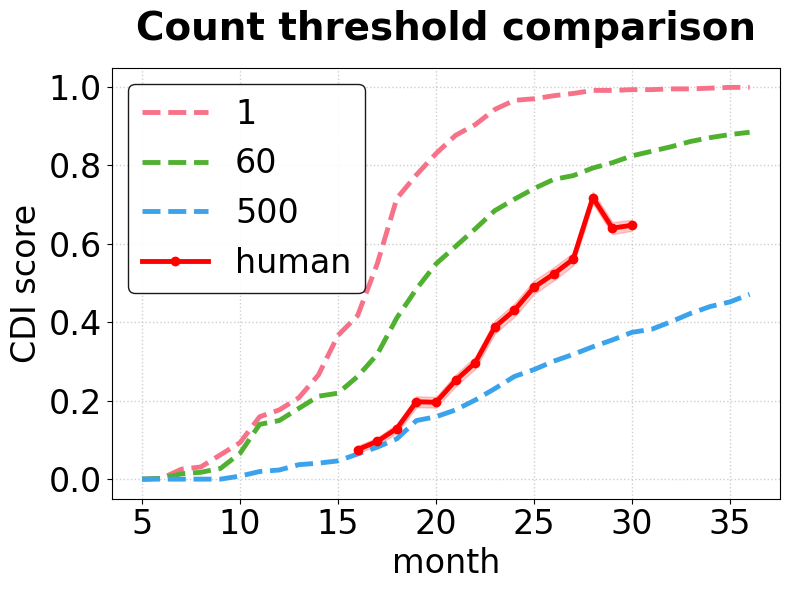

<Figure size 640x480 with 0 Axes>

In [627]:
human_cdi_path = data_root / "cdi_ws_na_childes.csv"
threshold_path = data_root / "metric_CDI_threshold_test.csv"
out_path = fig_path / "paper/threshold.pdf"
compare_thresholds(human_cdi_path, threshold_path, out_path)

# Core metrics

In [565]:
def plot_curves(df: pd.DataFrame, x_header: str, y_header: str, group_header: str, legend_title: str = None, y_lim: list[float] = [0, 1], out_path: Path | None = None) -> None:
    """Plot multiple curves by different groups with confidence intervals."""
    plt.figure(figsize=[8, 6])
    df_stats = DataLoader.calculate_statistics(df, [group_header], x_header, y_header)
    unique_conditions = df_stats[group_header].unique()
    for condition in unique_conditions:
        subset = df_stats[df_stats[group_header] == condition]
        plot_condition_curve(subset, condition, x_header, y_header="mean")

    configure_plot_style(x_label=x_header, y_label=y_header, legend_title=legend_title, grid=True, out_path=out_path, ylim=y_lim)


def compare_metrics(raw_data_path: str, out_path: Path):
    """Load data and plot final results."""
    # load data
    raw_data = pd.read_csv(raw_data_path)
    df = raw_data.dropna()
    # Sort by month and combine dataset + model_type for labels
    df = df.sort_values("month")
    df["condition"] = df["dataset"] + "(" + df["model_type"] + ")"

    metric_dict = {"CDI": [0, 1]}
    # metric_dict = {"type_token_ratio": [0, 1], "rej_type_rate": [0, 0.5], "rej_token_rate": [0, 0.5], "CDI": [0, 1]}
    for metric, ylim in metric_dict.items():
        sel_df = DataLoader.load_df(df, metric=metric, temp=1.0)
        out_path_file = out_path / f"{metric}.pdf"
        plot_curves(df=sel_df, x_header="month", y_header=metric, group_header="condition", y_lim=ylim, out_path=out_path_file)
    # plot out the labels
    # out_path_file = out_path / f"metric_label.png"
    # plot_curves(df=sel_df, x_header="month", y_header=metric, group_header="condition", y_lim=ylim,legend_title="Setting", out_path=out_path_file)


# vanilla freq matching

Current sampling ratio 4


<Figure size 1000x600 with 0 Axes>

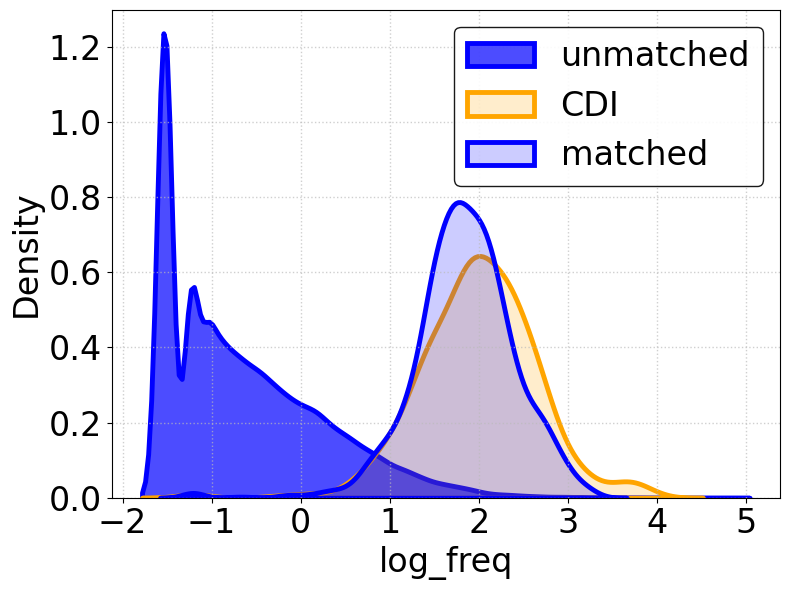

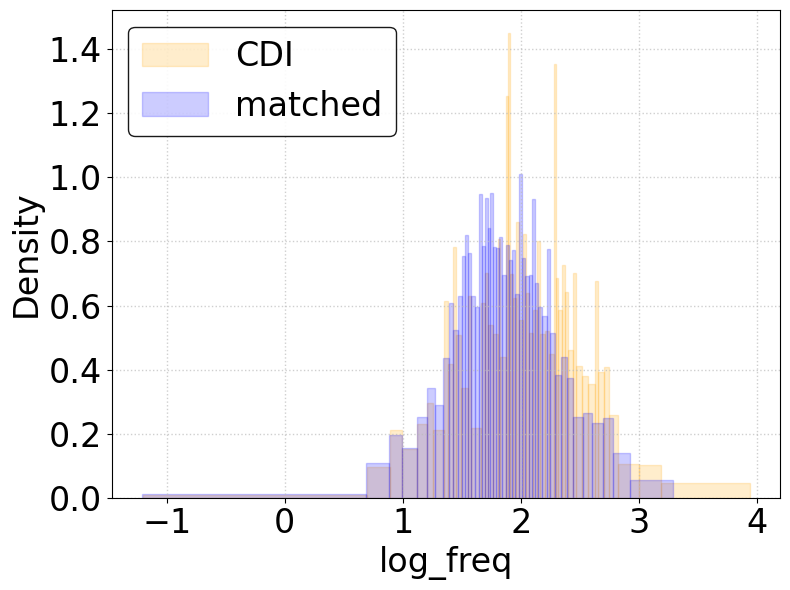

/Users/jliu/workspace/lexical_bencmark/dataset/fig/freq_before_after_legend.png


<Figure size 1200x600 with 0 Axes>

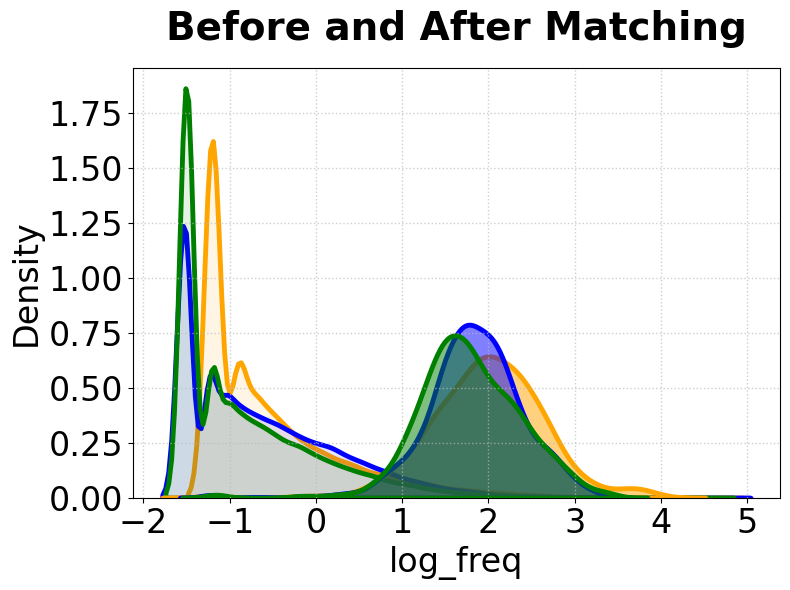

/Users/jliu/workspace/lexical_bencmark/dataset/fig/freq_matched_legend.png


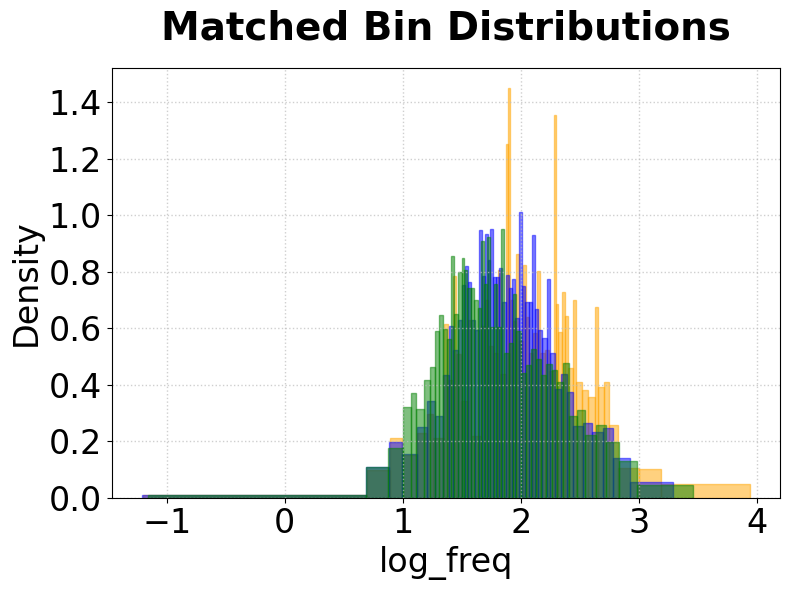

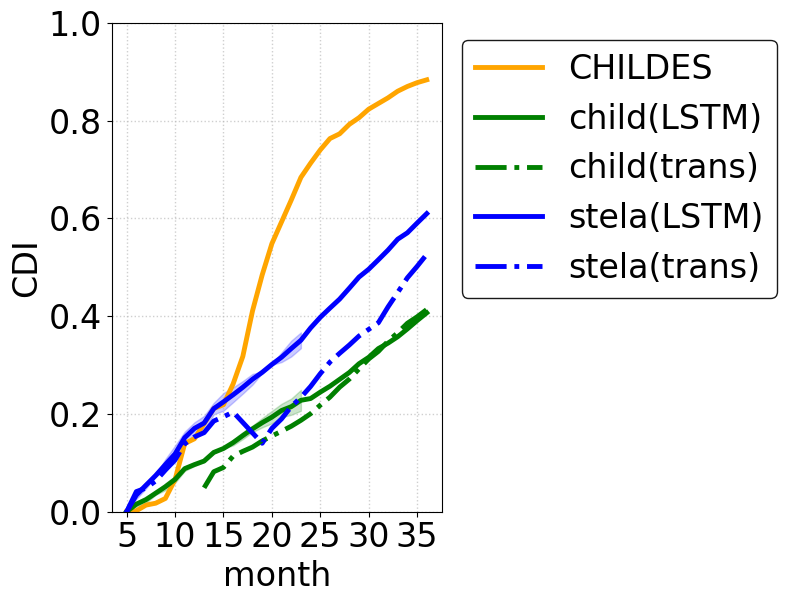

##################################################


In [683]:
# loop all the candidates
# load file
sampling_ratio_lst = [4]
freq_root = Path(f"{data_root}/word_freq")

for sampling_ratio in sampling_ratio_lst:
    print(f"Current sampling ratio {sampling_ratio}")
    file_root = Path(f"{data_root}/CDI_new/CDI_{sampling_ratio}")
    compare_freq_demo(file_root, freq_root, output_dir=fig_path / "paper")
    compare_freq(file_root, freq_root, output_dir=fig_path)
    compare_metrics(file_root / "metric_1000_4.csv", out_path=fig_path)
    print("##################################################")

# Temperature trade-off 

In [570]:
def plot_scatters(df: pd.DataFrame, x_header: str, y_header: str, group_header: str, y_lim: list[float] = [0, 1], out_path: Path | None = None) -> None:
    """Plot multiple curves by different groups with confidence intervals."""
    plt.figure(figsize=[10, 6])
    df_stats = DataLoader.calculate_statistics(df, [group_header, "temp"], x_header, y_header)
    unique_conditions = df_stats[group_header].unique()

    for condition in unique_conditions:
        subset = df_stats[df_stats[group_header] == condition]
        plot_condition_scatter(subset, condition, x_header, y_header="mean")

    configure_plot_style(x_label=x_header, y_label=y_header, fig_title=f"{y_header} and CDI", legend_title="Dataset", grid=True, out_path=out_path, ylim=y_lim)


def compare_temp(raw_data_path: str):
    """Load data and plot final results."""
    # load data
    raw_data = pd.read_csv(raw_data_path)
    df = raw_data.dropna()
    # Sort by month and combine dataset + model_type for labels
    df = df.sort_values("month")
    df["condition"] = df["dataset"] + "(" + df["model_type"] + ")"

    metric_dict = {"type_token_ratio": [0, 0.6], "rej_type_rate": [0, 0.4], "rej_token_rate": [0, 0.4]}
    for metric, ylim in metric_dict.items():
        sel_df = DataLoader.load_temp_df(df, x_header="CDI", y_header=metric)
        plot_scatters(df=sel_df, x_header="CDI", y_header=metric, group_header="condition", y_lim=ylim)


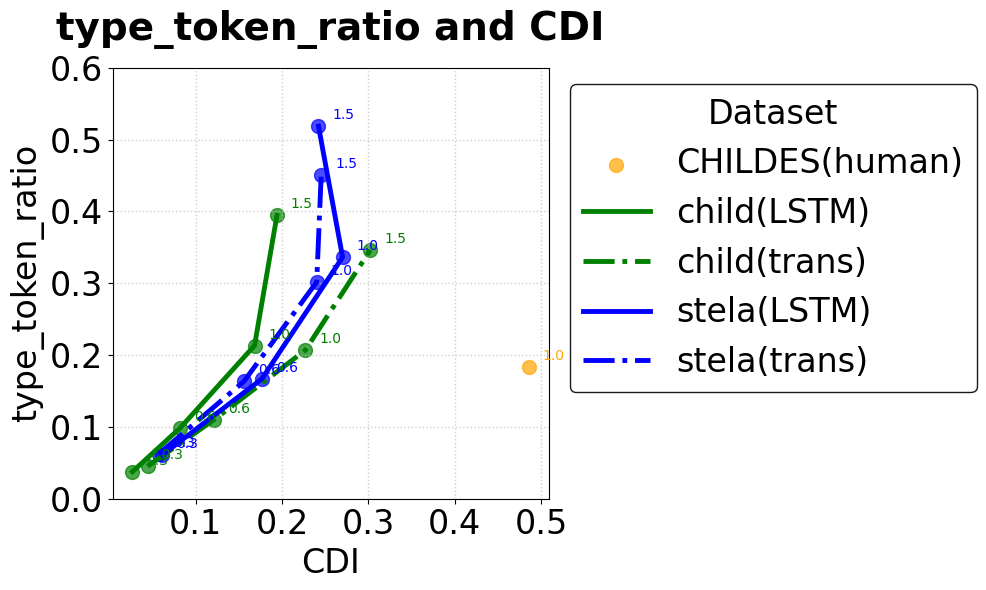

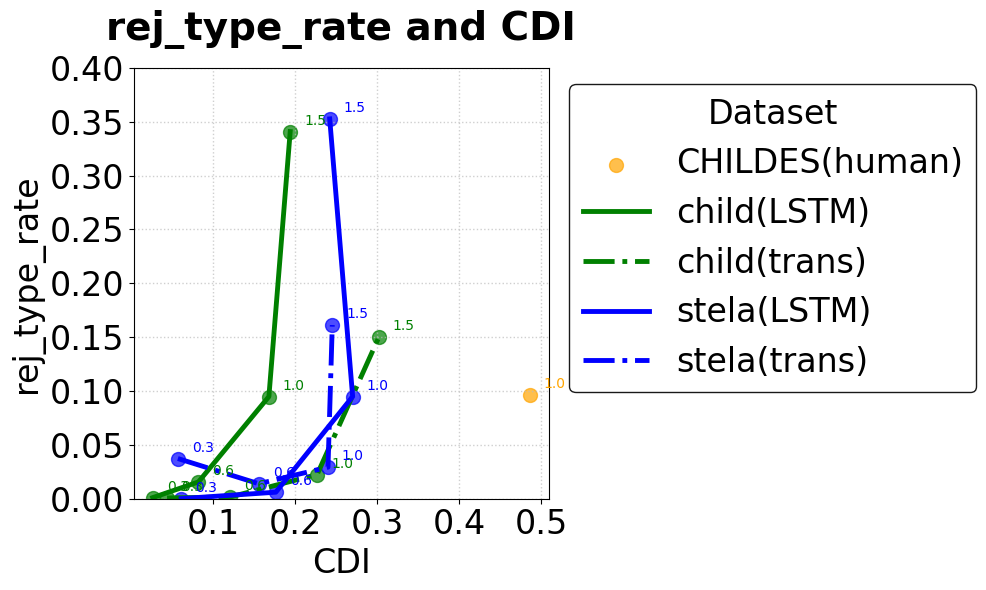

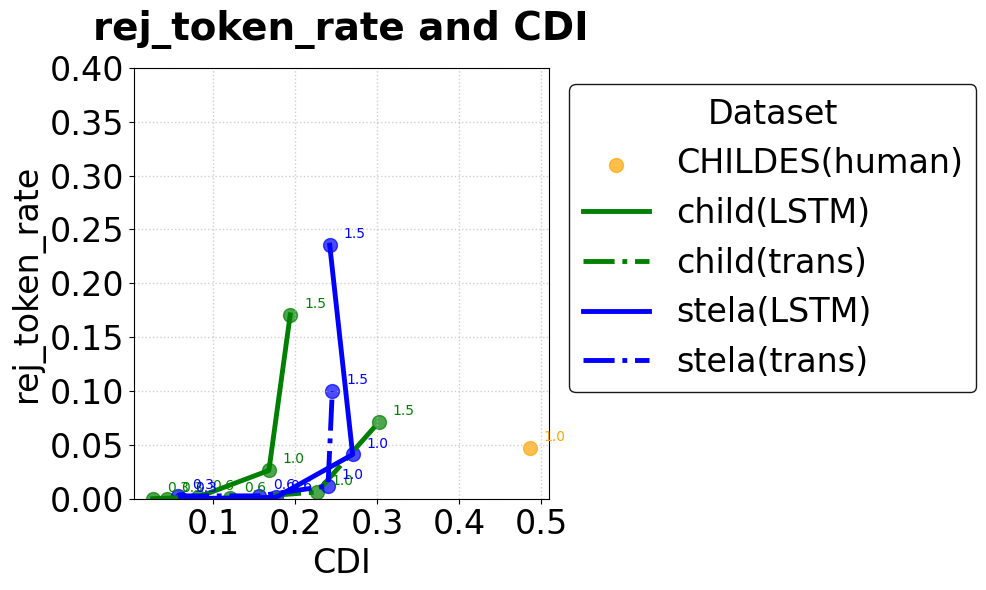

In [571]:
sampling_ratio = 4
raw_data_path = f"/Users/jliu/workspace/lexical_bencmark/dataset/CDI_new/CDI_{sampling_ratio}/metric_1000_4.csv"
compare_temp(raw_data_path)

# Extrapolated metrics

In [288]:
def plot_sigmoid(df: pd.DataFrame, x_header: str, y_header: str, group_header: str, target_y: float = 0.8, y_lim: list[float] = [0, 1], out_path: Path | None = None) -> None:
    """Plot multiple curves by different groups with confidence intervals."""
    plt.figure(figsize=PlotSettings.DEFAULTS["figsize"])

    unique_conditions = df[group_header].unique()
    for condition in unique_conditions:
        # Get subset for this condition
        subset = df[df[group_header] == condition]

        # Fit sigmoid for this condition
        sigmoid_fitter = SigmoidFitter(x_data=subset[x_header], y_data=subset[y_header], target_y=target_y)
        params = sigmoid_fitter.fit_sigmoid()

        # Plot this condition
        plot_condition_sigmoid(subset, condition, x_header, y_header, params)

    configure_plot_style(x_label=x_header, y_label=y_header, fig_title=f"{y_header} by months", legend_title="Setting", grid=True, out_path=out_path, ylim=y_lim)


def compare_sigmoid(raw_data_path: str, target_y: float = 0.8):
    """Load data and plot final results."""
    # load data
    raw_data = pd.read_csv(raw_data_path)
    df = raw_data.dropna()

    # Sort by month and combine dataset + model_type for labels
    df = df.sort_values("month")
    df["condition"] = df["dataset"] + "(" + df["model_type"] + ")"

    metric_dict = {"CDI": [0, 1]}
    for metric, ylim in metric_dict.items():
        sel_df = DataLoader.load_sigmoid_df(df, metric="CDI")
        # loop over different temperatures; output the results of each freq band
        for temp in 
        #plot_sigmoid(df=sel_df, x_header="month", y_header="CDI", group_header="condition", target_y=target_y, y_lim=ylim)




In [289]:
# TODO: loop over diffreent temperatures
sampling_ratio = 1
raw_data_path = f"/Users/jliu/workspace/lexical_bencmark/dataset/CDI_{sampling_ratio}/metric_1000_4.csv"
compare_sigmoid(raw_data_path)

        condition  temp  dataset model_type      word_num  chunk  month
0  CHILDES(human)   1.0  CHILDES      human  80574.625000      0     36
1     child(LSTM)   0.3    child       LSTM  52914.313725      1     36
2     child(LSTM)   0.6    child       LSTM  52914.313725      0     36
3     child(LSTM)   1.0    child       LSTM  52914.333333      0     36
4     child(LSTM)   1.5    child       LSTM  52914.313725      0     36
5     stela(LSTM)   0.3    stela       LSTM  52914.313725      1     36
6     stela(LSTM)   0.6    stela       LSTM  52914.313725      1     36
7     stela(LSTM)   1.0    stela       LSTM  52914.313725      1     36
8     stela(LSTM)   1.5    stela       LSTM  52914.313725      1     36
################################


/var/folders/c2/336gdlh133qfynjgt7nm9jhw0000gn/T/ipykernel_60506/2841215940.py:53: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[metric] = df[metric].fillna(method="ffill")
